# Initail Setup

In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from one.api import ONE
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from iblatlas.regions import BrainRegions
from iblatlas.plots import plot_scalar_on_slice
from iblatlas.atlas import AllenAtlas
from iblatlas.flatmaps import FlatMap
from iblatlas.plots import plot_swanson_vector
from iblatlas.plots import plot_scalar_on_flatmap
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from scipy import stats
from scipy.signal import butter, filtfilt
import pickle
import matplotlib as mpl
from brainbox.ephys_plots import image_fr_plot
from iblutil.numerical import bincount2D

In [8]:
# Candidate sessions:

# subject = "UCLA_037"
# eid = "bda2faf5-9563-4940-a80f-ce444259e47b"
# pid = "29418b18-4db6-436f-a85e-b0f1d38d2e62"

In [2]:
# Define Constants / Configuration
CONFIG = {
    'REVISION': '2024-05-06', 
    'TASK_EXCLUDE_WINDOW_PRE': 0.2, 
    'TASK_EXCLUDE_WINDOW_POST': 0.5,
    'LP_FILTER_HZ': 20,
    'MAX_SESSIONS_TO_PROCESS': None, 
    'CCG_BIN_SIZE': 0.001, 
    'CCG_WINDOW_SIZE': 0.2,
    'COUPLING_METHOD': 'sta', # 'correlation' or 'sta'
}

In [3]:
# Define and create project paths
base_path = Path(r"C:/Users/Experiment/Documents/Amirreza/SeqProject2026")
path_data = base_path / "data"
path_fig = base_path / "results" / "figures"
path_data_processed = path_data / "processed"
ibl_cache = path_data / 'raw'

# Create directories
for p in [ibl_cache, path_fig, path_data_processed]:
    p.mkdir(exist_ok=True, parents=True)

print(f"Directories ready. Cache: {ibl_cache}")

# Setup the ONE API with custom cache directory
try:
    one = ONE(base_url='https://openalyx.internationalbrainlab.org', password='international', silent=True, cache_dir=ibl_cache)
    print("ONE API initialized.")
except Exception as e:
    print(f"Error initializing ONE: {e}")

# Setup AllenAtlas
ba = AllenAtlas()

Directories ready. Cache: C:\Users\Experiment\Documents\Amirreza\SeqProject2026\data\raw
ONE API initialized.


In [4]:
br = BrainRegions()
beryl_indices = np.unique(br.mappings['Beryl'])
beryl_acronyms = br.acronym[beryl_indices]
beryl_acronyms = np.delete(beryl_acronyms, np.where(beryl_acronyms == ['void']))
beryl_acronyms = np.delete(beryl_acronyms, np.where(beryl_acronyms == ['root']))
for region in beryl_acronyms:
    os.makedirs(f"{path_data}/session_plots_integrated/{region}/", exist_ok=True)

# check with hierarchical level
hier_file = os.path.join(path_data, "hierarchy_summary_CreConf_all_regions.csv")
hier_df = pd.read_csv(hier_file)

# Build a mapping from beryl_acronyms to hierarchical score
area_to_hier_score = dict(zip(hier_df["areas"], hier_df["CC+TC+CT iterated"]))

# Get hierarchical scores for each beryl_acronym (NaN if not found)
hier_scores = np.array([area_to_hier_score.get(region, np.nan) for region in beryl_acronyms])

# Session Selection, Download and Load

In [5]:
tag = '2025_Q3_IBL_et_al_BWM' 
brain_acronym = 'VISp'

# query sessions endpoint
sessions = one.search(tag=tag, atlas_acronym=brain_acronym, query_type='remote')
print(f'No. of detected sessions: {len(sessions)}')

# query insertions endpoint
insertions = one.search_insertions(tag=tag, atlas_acronym=brain_acronym)
print(f'No. of detected insertions: {len(insertions)}')

No. of detected sessions: 62
No. of detected insertions: 67


In [6]:
# Define the Probe Insertion ID (PID)
pid = 'c9664185-d3fd-4e0e-89cf-77c402038938' # Used by Celian
# '3d3d5a5e-df26-43ee-80b6-2d72d85668a5' 

print(f"\nProcessing PID: {pid}")

# Initialize SpikeSortingLoader
ssl = SpikeSortingLoader(pid=pid, one=one, atlas=ba)
print(f"Session ID (EID): {ssl.eid}")
print(f"Probe Name: {ssl.pname}")

# Load Spiking Neural Data (Spikes, Clusters, Channels)
# load_spike_sorting() downloads and loads the data efficiently
spikes, clusters, channels = ssl.load_spike_sorting()

# IMPORTANT: Merge clusters with channel data to get brain region acronyms and coordinates
clusters = ssl.merge_clusters(spikes, clusters, channels)

print(f"Spikes loaded: {spikes.times.shape[0]} spikes")
if 'acronym' in clusters:
    print(f"Cluster regions found: {set(clusters.acronym)}")

# Load Trial Data using SessionLoader
sl = SessionLoader(eid=ssl.eid, one=one)
sl.load_trials()
print(f"Trials loaded. Found keys: {list(sl.trials.keys())}")
trials = sl.trials
sl.load_wheel()
print(f"Wheel data loaded. Found keys: {list(sl.wheel.keys())}")
sl.load_pose(views=['left', 'right'])
print(f"Pose data loaded. Found keys: {list(sl.pose.keys())}")

# Initialize containers for pupil data
pupil_features = None
pupil_times = None
try:
    print("Loading leftCamera data (features and times)...")
    # Explicitly load camera object using ONE as per IBL documentation
    # This downloads _ibl_leftCamera.features.pqt and _ibl_leftCamera.times.npy
    # We assume 'sl' (SessionLoader) is defined in the environment
    left_camera = sl.one.load_object(sl.eid, 'leftCamera', collection='alf')
    
    # Check if we have the necessary attributes
    if hasattr(left_camera, 'features') and hasattr(left_camera, 'times'):
        pupil_features = left_camera.features
        pupil_times = left_camera.times
        print("Camera data loaded successfully.")
    else:
        print("Camera object loaded but 'features' or 'times' attribute missing.")

except Exception as e:
    print(f"Could not load pupil data: {e}")


Processing PID: c9664185-d3fd-4e0e-89cf-77c402038938
Session ID (EID): e349a2e7-50a3-47ca-bc45-20d1899854ec
Probe Name: probe01


c:\Users\Experiment\anaconda3\envs\Seq2026\Lib\site-packages\one\util.py:414: ALFWarning: No default revision for dataset alf/probe01/pykilosort/#2024-03-12#/clusters.metrics.pqt; using most recent
  warnings.warn(


Spikes loaded: 28721702 spikes
Cluster regions found: {'VISpl6a', 'VISp6a', 'ENTm2', 'ENTm1', 'VISp1', 'HPF', 'void', 'ENTm5', 'ENTm3', 'VISp4', 'VISp5', 'VISp2/3', 'ec'}


c:\Users\Experiment\anaconda3\envs\Seq2026\Lib\site-packages\one\util.py:436: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


Trials loaded. Found keys: ['goCueTrigger_times', 'intervals_bpod_0', 'intervals_bpod_1', 'quiescencePeriod', 'stimOffTrigger_times', 'stimOff_times', 'stimOnTrigger_times', 'goCue_times', 'response_times', 'choice', 'stimOn_times', 'contrastLeft', 'contrastRight', 'probabilityLeft', 'feedback_times', 'feedbackType', 'rewardVolume', 'firstMovement_times', 'intervals_0', 'intervals_1']
Wheel data loaded. Found keys: ['times', 'position', 'velocity', 'acceleration']


c:\Users\Experiment\anaconda3\envs\Seq2026\Lib\site-packages\one\util.py:436: ALFWarning: Multiple revisions: "", "2023-04-20"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


Pose data loaded. Found keys: ['leftCamera', 'rightCamera']
Loading leftCamera data (features and times)...


c:\Users\Experiment\anaconda3\envs\Seq2026\Lib\site-packages\one\util.py:436: ALFWarning: Multiple revisions: "", "2025-06-04", "2025-05-31"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


Camera data loaded successfully.


# Behavioural Data

In [6]:
reaction_time = sl.trials['response_times'] - sl.trials['stimOn_times']

correct_trial_idx = sl.trials['feedbackType'] == 1
incorrect_trial_idx = sl.trials['feedbackType'] == -1
correct_reaction_time = np.mean(reaction_time[correct_trial_idx])
incorrect_reaction_time = np.mean(reaction_time[incorrect_trial_idx])

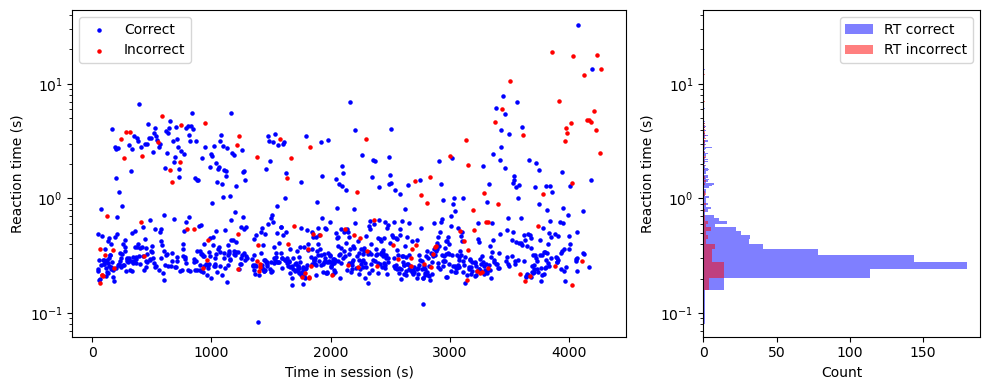

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [2, 1]})  # Adjust figsize as needed

# Scatter plot on the left (ax1)
ax1.scatter(sl.trials['stimOn_times'][correct_trial_idx], reaction_time[correct_trial_idx], c='blue', s=5, label='Correct')
ax1.scatter(sl.trials['stimOn_times'][incorrect_trial_idx], reaction_time[incorrect_trial_idx], c='red', s=5, label='Incorrect')
ax1.set_yscale("log")
ax1.set_xlabel('Time in session (s)')
ax1.set_ylabel('Reaction time (s)')
ax1.legend()

# Histogram on the right (ax2)
ax2.hist(reaction_time[correct_trial_idx], bins=np.linspace(0, 20, 500), color='blue', alpha=0.5, label='RT correct', orientation='horizontal')
ax2.hist(reaction_time[incorrect_trial_idx], bins=np.linspace(0, 20, 500), color='red', alpha=0.5, label='RT incorrect', orientation='horizontal')
ax2.legend()
ax2.set_xlabel('Count')
ax2.set_ylabel('Reaction time (s)')
ax2.set_yscale("log")
ax2.set_ylim(ax1.get_ylim())  # Sync y-axis limits with scatter plot

plt.tight_layout()  # Adjust spacing between subplots
#To see the output, run the code.

# Single Trial Raster Plots

In [9]:
# Update CONFIG with Raster Plot constants
CONFIG.update({
    'RASTER_TRIAL_IDX': 55,          # The specific trial index to plot
    'RASTER_WINDOW_PRE': 1,           # Seconds before Stim On
    'RASTER_WINDOW_POST': 2,          # Seconds after Feedback
    'RASTER_ONLY_GOOD_UNITS': False,   # Set to False to plot ALL neurons
    'RASTER_ALIGN_TO_STIM_ON': True,  # Set True to make Stim On = 0s, False for Session Time
})


# Flag to save the figure (Standalone variable, not in CONFIG)
SAVE_FIGURE = True

Pupil data found in window: 249 frames.
Figure saved to: C:\Users\Experiment\Documents\Amirreza\SeqProject2026\results\figures\c9664185-d3fd-4e0e-89cf-77c402038938_55_Raster.png


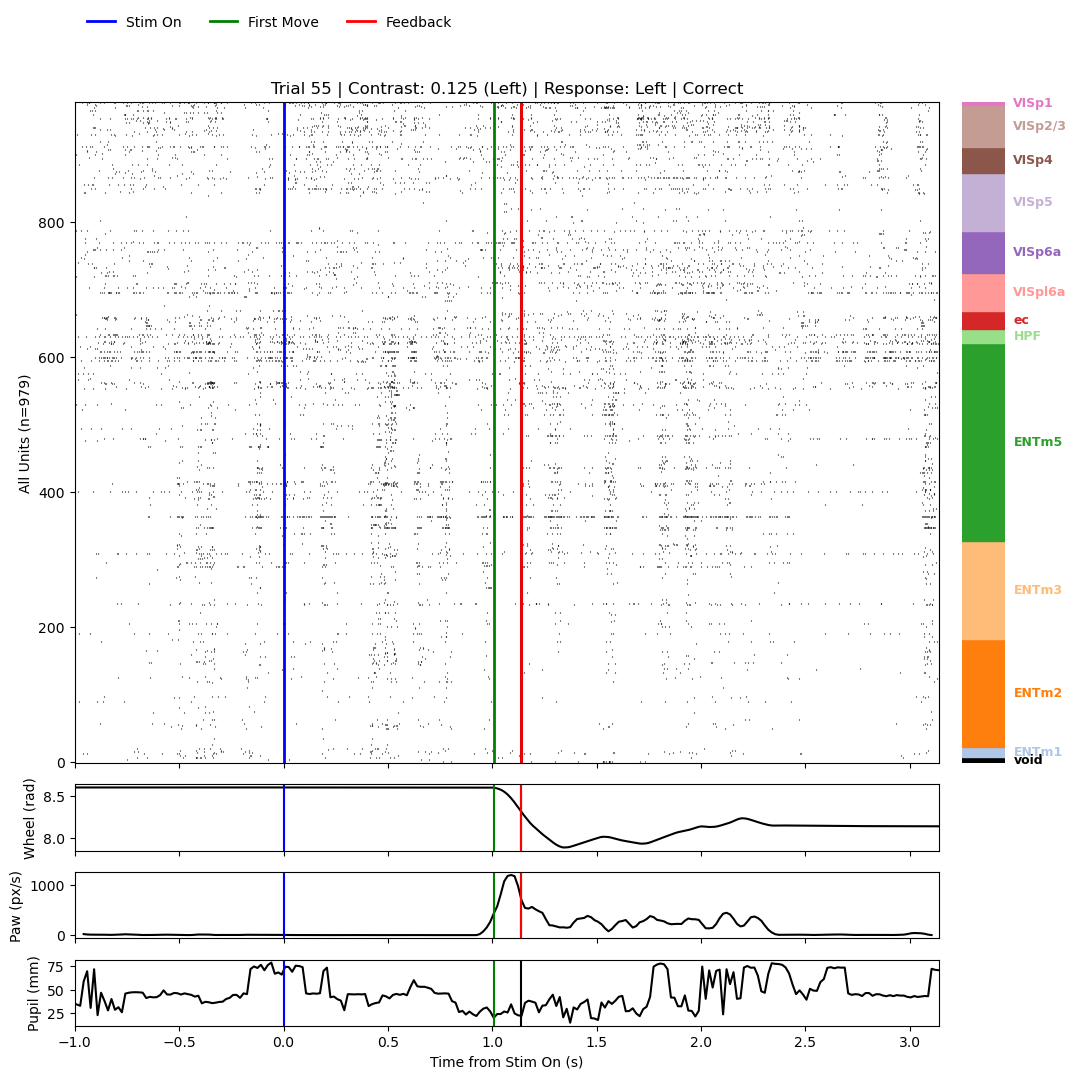

In [ ]:
trial_idx = CONFIG['RASTER_TRIAL_IDX']

# Ensure 'sl' (SessionLoader) is defined in your environment
t_stim_on = sl.trials['stimOn_times'][trial_idx]
t_first_move = sl.trials['firstMovement_times'][trial_idx]
t_feedback = sl.trials['feedback_times'][trial_idx]
t_response = sl.trials['response_times'][trial_idx]

# Define the absolute time window for data filtering
t_start = t_stim_on - CONFIG['RASTER_WINDOW_PRE']
t_end = t_feedback + CONFIG['RASTER_WINDOW_POST']

# Determine Alignment Offset
if CONFIG['RASTER_ALIGN_TO_STIM_ON']:
    t_offset = t_stim_on
    xlabel_text = 'Time from Stim On (s)'
else:
    t_offset = 0
    xlabel_text = 'Time in session (s)'

# --- Retrieve Trial Metadata for Title ---
# Handle contrast (check for NaN to determine side)
cont_l = sl.trials['contrastLeft'][trial_idx]
cont_r = sl.trials['contrastRight'][trial_idx]

if not np.isnan(cont_l):
    contrast_val = cont_l
    stim_side = 'Left'
elif not np.isnan(cont_r):
    contrast_val = cont_r
    stim_side = 'Right'
else:
    contrast_val = 0
    stim_side = 'Zero'

# Handle Choice (-1: Right, 1: Left, 0: NoGo)
choice_map = {1: 'Left', -1: 'Right', 0: 'NoGo'}
choice_val = sl.trials['choice'][trial_idx]
response_str = choice_map.get(choice_val, str(choice_val))

# Handle Feedback (1: Correct, -1: Incorrect)
fb_val = sl.trials['feedbackType'][trial_idx]
outcome_str = 'Correct' if fb_val == 1 else 'Incorrect'

plot_title = f"Trial {trial_idx} | Contrast: {contrast_val} ({stim_side}) | Response: {response_str} | {outcome_str}"


# 2. Process Spike Data
# Select units based on configuration
if CONFIG['RASTER_ONLY_GOOD_UNITS']:
    # Filter for "good" clusters only (label == 1)
    target_indices = np.where(clusters.label == 1)[0]
    ylabel_text = f'Good Units (n={len(target_indices)})'
else:
    # Use all clusters
    target_indices = np.arange(len(clusters.label))
    ylabel_text = f'All Units (n={len(target_indices)})'

# Create a DataFrame for easier sorting/grouping
df_units = pd.DataFrame({
    'id': target_indices,
    'acronym': clusters.acronym[target_indices],
    'depth': clusters.depths[target_indices]
})

# Sort by depth ASCENDING (Deep -> Surface)
df_units = df_units.sort_values(by='depth', ascending=True).reset_index(drop=True)

# Map acronyms to colors for the sidebar
unique_regions = df_units['acronym'].unique()
region_colors = {reg: plt.cm.tab20(i % 20) for i, reg in enumerate(unique_regions)}
region_colors['void'] = 'black'

# Filter spikes for the time window GLOBALLY first (using absolute times)
mask_window = (spikes.times >= t_start) & (spikes.times <= t_end)
window_spike_times = spikes.times[mask_window]
window_spike_clusters = spikes.clusters[mask_window]

# 3. Process Behavioral Data
# --- Wheel Data ---
mask_wheel = (sl.wheel['times'] >= t_start) & (sl.wheel['times'] <= t_end)
wheel_t = sl.wheel['times'][mask_wheel]
wheel_pos = sl.wheel['position'][mask_wheel]

# --- Paw Speed Data ---
pose_t = None
paw_speed = None
if hasattr(sl, 'pose') and 'leftCamera' in sl.pose:
    pose_df = sl.pose['leftCamera']
    if 'times' in pose_df.columns:
        pose_timestamps = pose_df['times'].values
    else:
        pose_timestamps = pose_df.index.values

    mask_pose = (pose_timestamps >= t_start) & (pose_timestamps <= t_end)
    pose_t = pose_timestamps[mask_pose]
    
    # Calculate Speed
    paw_key = 'paw_r' if 'paw_r_x' in pose_df.columns else 'paw_l'
    if f'{paw_key}_x' in pose_df.columns:
        dx = np.gradient(pose_df[f'{paw_key}_x'].values[mask_pose])
        dy = np.gradient(pose_df[f'{paw_key}_y'].values[mask_pose])
        dt = np.gradient(pose_t)
        dt[dt == 0] = np.nan
        speed_raw = np.sqrt(dx**2 + dy**2) / dt
        paw_speed = pd.Series(speed_raw).fillna(0).rolling(window=5, center=True).mean().values

# --- Pupil Diameter Data ---
pupil_t = None
pupil_diam = None

if pupil_features is not None and pupil_times is not None:
    # Identify the correct diameter column
    diam_col = 'pupilDiameter_raw'
    
    if diam_col in pupil_features.columns:
        # Handle potential length mismatch (though unlikely in valid datasets)
        n_frames = min(len(pupil_times), len(pupil_features))
        
        # Slice valid data
        pt = pupil_times[:n_frames]
        pd_vals = pupil_features[diam_col].values[:n_frames]
        
        # Filter for the trial window
        mask_pupil = (pt >= t_start) & (pt <= t_end)
        pupil_t = pt[mask_pupil]
        pupil_diam = pd_vals[mask_pupil]
        print(f"Pupil data found in window: {len(pupil_t)} frames.")

# 4. Generate Plot
fig = plt.figure(figsize=(12, 12)) # Increased height for extra plot
# Adjusted height_ratios to make behavioral plots smaller [Raster, Wheel, Paw, Pupil]
gs = gridspec.GridSpec(4, 2, width_ratios=[20, 1], height_ratios=[10, 1, 1, 1], wspace=0.05, hspace=0.1)

# -- Raster Plot (Top Left) --
ax_raster = fig.add_subplot(gs[0, 0])

# Iterate through sorted units and plot using vlines (adjusting for offset)
for y_idx, row in df_units.iterrows():
    unit_spike_times = window_spike_times[window_spike_clusters == row['id']]
    if len(unit_spike_times) > 0:
        # Subtract offset to align relative to stim on if requested
        ax_raster.vlines(unit_spike_times - t_offset, y_idx - 0.45, y_idx + 0.45, color='k', linewidth=0.8)

# Events (Adjusted for offset)
for ax in [ax_raster]:
    ax.axvline(t_stim_on - t_offset, color='blue', linestyle='-', linewidth=2, label='Stim On')
    ax.axvline(t_first_move - t_offset, color='green', linestyle='-', linewidth=2, label='First Move')
    ax.axvline(t_response - t_offset, color='black', linestyle='-', linewidth=2, label='Response')
    ax.axvline(t_feedback - t_offset, color='red', linestyle='-', linewidth=2, label='Feedback')

# Set Limits relative to offset
ax_raster.set_xlim(t_start - t_offset, t_end - t_offset)
ax_raster.set_ylim(-1, len(df_units))
ax_raster.set_ylabel(ylabel_text)
ax_raster.set_title(plot_title)
# Hide x-axis labels for raster
ax_raster.tick_params(labelbottom=False)

# -- Region Color Bar (Top Right) --
ax_regions = fig.add_subplot(gs[0, 1])
y_min = 0
for acronym, group in df_units.groupby('acronym', sort=False):
    count = len(group)
    color = region_colors.get(acronym, 'gray')
    ax_regions.add_patch(plt.Rectangle((0, y_min), 1, count, color=color))
    ax_regions.text(1.2, y_min + count/2, acronym, va='center', fontsize=9, color=color, fontweight='bold')
    y_min += count

ax_regions.set_ylim(0, len(df_units))
ax_regions.axis('off')

# -- Wheel Position (2nd Row) --
ax_wheel = fig.add_subplot(gs[1, 0], sharex=ax_raster)
ax_wheel.plot(wheel_t - t_offset, wheel_pos, color='black')
ax_wheel.set_ylabel('Wheel (rad)')
ax_wheel.axvline(t_stim_on - t_offset, color='blue', linewidth=1.5)
ax_wheel.axvline(t_first_move - t_offset, color='green', linewidth=1.5)
ax_wheel.axvline(t_response - t_offset, color='black', linewidth=1.5)
ax_wheel.axvline(t_feedback - t_offset, color='red', linewidth=1.5)
ax_wheel.tick_params(labelbottom=False)

# -- Paw Speed (3rd Row) --
ax_paw = fig.add_subplot(gs[2, 0], sharex=ax_raster)
if paw_speed is not None:
    ax_paw.plot(pose_t - t_offset, paw_speed, color='black')
else:
    ax_paw.text(0.5, 0.5, "Paw data not available", ha='center', transform=ax_paw.transAxes)

ax_paw.set_ylabel('Paw (px/s)')
ax_paw.axvline(t_stim_on - t_offset, color='blue', linewidth=1.5)
ax_paw.axvline(t_first_move - t_offset, color='green', linewidth=1.5)
ax_paw.axvline(t_response - t_offset, color='black', linewidth=1.5)
ax_paw.axvline(t_feedback - t_offset, color='red', linewidth=1.5)
ax_paw.tick_params(labelbottom=False)

# -- Pupil Diameter (4th Row) --
ax_pupil = fig.add_subplot(gs[3, 0], sharex=ax_raster)
if pupil_diam is not None:
    ax_pupil.plot(pupil_t - t_offset, pupil_diam, color='black')
else:
    ax_pupil.text(0.5, 0.5, "Pupil data not available", ha='center', transform=ax_pupil.transAxes)

ax_pupil.set_ylabel('Pupil (mm)')
ax_pupil.set_xlabel(xlabel_text)
ax_pupil.axvline(t_stim_on - t_offset, color='blue', linewidth=1.5)
ax_pupil.axvline(t_first_move - t_offset, color='green', linewidth=1.5)
ax_pupil.axvline(t_response - t_offset, color='black', linewidth=1.5)
ax_pupil.axvline(t_feedback - t_offset, color='red', linewidth=1.5)
ax_pupil.tick_params(labelbottom=True)

# Legend
lines = [
    plt.Line2D([0], [0], color='blue', linewidth=2),
    plt.Line2D([0], [0], color='green', linewidth=2),
    plt.Line2D([0], [0], color='red', linewidth=2)
]
ax_raster.legend(lines, ['Stim On', 'First Move', 'Feedback'], loc='upper left', frameon=False, bbox_to_anchor=(0, 1.15), ncol=3)

# Save the figure if requested
if SAVE_FIGURE:
    # Ensure 'pid' and 'path_fig' are defined in the environment
    # Filename format: PID_Trial ID_Raster
    filename = f"{pid}_{trial_idx}_Raster.png"
    save_path = path_fig / filename
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Figure saved to: {save_path}")

plt.show()

# Single Neuron PSTH

Processing 1022 trials...
Found 979 clusters.
Computed delays for 979 neurons.
Filtered to 59 good, responsive units.


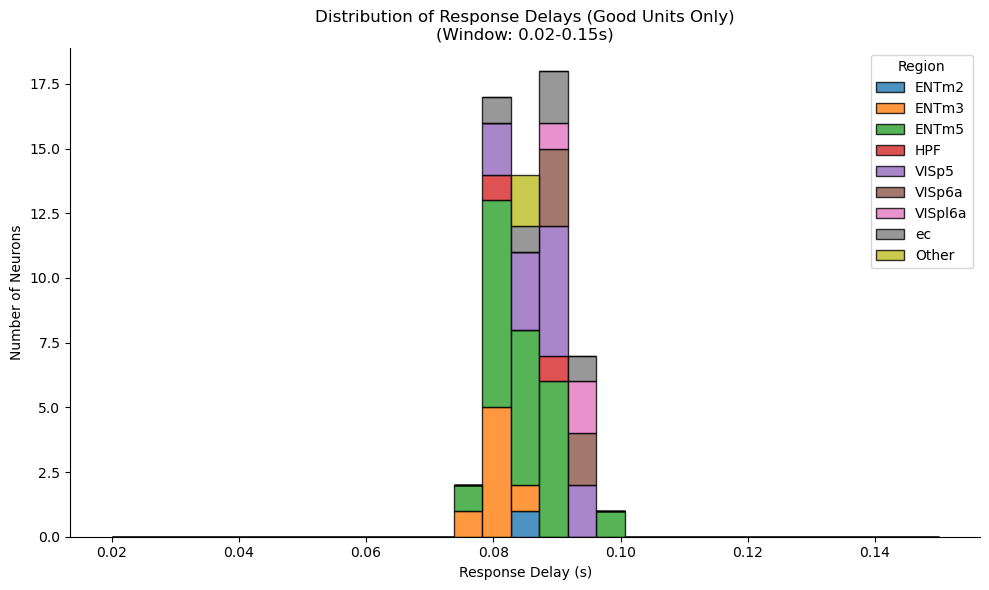


Summary Statistics by Region:
             count      mean       std
plot_region                           
ENTm2          1.0  0.084372       NaN
ENTm3          7.0  0.081109  0.001886
ENTm5         22.0  0.084369  0.004975
HPF            2.0  0.084790  0.003627
Other          2.0  0.083605  0.000683
VISp5         12.0  0.087470  0.004020
VISp6a         5.0  0.092588  0.002325
VISpl6a        3.0  0.092292  0.001155
ec             5.0  0.087089  0.003893


In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d

# ==========================================
# CONFIGURATION
# ==========================================
CONFIG = {
    'WINDOW_START': 0.02,           # Start of responsive window (s) (10ms)
    'WINDOW_END': 0.150,             # End of responsive window (s) (300ms)
    'BASELINE_PRE': 0.2,            # Baseline window duration before stim (s)
    'BIN_SIZE': 0.005,              # Bin size for PSTH (5ms)
    'SMOOTH_SIGMA': 1,              # Sigma for gaussian smoothing (in bins). 1 bin ~ 5ms.
    'PLOT_ONLY_GOOD_UNITS': True,   # Flag: Plot only "good" units (label=1)
    'MIN_TRIALS': 50                # Minimum trials required to process a neuron
}

# ==========================================
# 1. PREPARE DATA
# ==========================================

# Valid events (Stimulus Onset) - Left and Right combined
events = sl.trials.stimOn_times[~np.isnan(sl.trials.stimOn_times)]
n_trials = len(events)

print(f"Processing {n_trials} trials...")

# Unique clusters
cluster_ids = np.unique(spikes.clusters)
print(f"Found {len(cluster_ids)} clusters.")

# Prepare storage for results
results = []

# Time vector for PSTH
# From -BASELINE_PRE to WINDOW_END + buffer
t_min = -CONFIG['BASELINE_PRE']
t_max = CONFIG['WINDOW_END'] + 0.05
bins = np.arange(t_min, t_max + CONFIG['BIN_SIZE'], CONFIG['BIN_SIZE'])
bin_centers = (bins[:-1] + bins[1:]) / 2

# Indices for specific windows
# Baseline: -0.2 to 0
idx_baseline = (bin_centers >= -CONFIG['BASELINE_PRE']) & (bin_centers < 0)
# Responsive: 0.01 to 0.3
idx_responsive = (bin_centers >= CONFIG['WINDOW_START']) & (bin_centers <= CONFIG['WINDOW_END'])

# ==========================================
# 2. CALCULATE DELAYS (Center of Mass)
# ==========================================

for cid in cluster_ids:
    # --- A. Filter Spikes for Cluster ---
    neuron_spikes = spikes.times[spikes.clusters == cid]
    
    # --- B. Compute PSTH (Vectorized) ---
    # We want relative times: spike_time - event_time
    # Creating a giant matrix (n_spikes x n_trials) is memory heavy.
    # Instead, we define the search window around events and extract.
    
    # Optimization: Chunk events or iterate if memory is an issue. 
    # For <1000 trials, simple iteration to collect relative spikes is usually fine.
    relative_spikes = []
    
    # Pre-filter spikes to overall range of interest to speed up trial loop
    # Min possible time: first event - baseline
    # Max possible time: last event + window end
    if len(neuron_spikes) == 0:
        continue
        
    s_min = events.min() - CONFIG['BASELINE_PRE']
    s_max = events.max() + CONFIG['WINDOW_END']
    subset_spikes = neuron_spikes[(neuron_spikes >= s_min) & (neuron_spikes <= s_max)]
    
    if len(subset_spikes) == 0:
        continue

    # Accumulate spikes relative to events
    # (Using a simple loop here for clarity and safety against memory overflows)
    for t_ev in events:
        t0 = t_ev - CONFIG['BASELINE_PRE']
        t1 = t_ev + CONFIG['WINDOW_END']
        # Get spikes in this trial window
        in_trial = subset_spikes[(subset_spikes >= t0) & (subset_spikes <= t1)]
        relative_spikes.append(in_trial - t_ev)
    
    if len(relative_spikes) == 0:
        continue
        
    all_rel_spikes = np.concatenate(relative_spikes)
    
    # Histogram
    counts, _ = np.histogram(all_rel_spikes, bins=bins)
    # Firing rate (Hz)
    fr = counts / n_trials / CONFIG['BIN_SIZE']
    
    # Smooth (Optional but recommended for stability)
    fr_smooth = gaussian_filter1d(fr, sigma=CONFIG['SMOOTH_SIGMA'])
    
    # --- C. Check Responsiveness ---
    # Baseline stats
    baseline_fr = fr_smooth[idx_baseline]
    if len(baseline_fr) == 0:
        continue
        
    mean_base = np.mean(baseline_fr)
    std_base = np.std(baseline_fr)
    
    # Threshold: Mean + 2 * STD
    threshold = mean_base + 2 * std_base
    
    # Responsive window data
    resp_fr = fr_smooth[idx_responsive]
    resp_time = bin_centers[idx_responsive]
    
    # Condition: Is there any bin in the responsive window > threshold?
    is_responsive = np.any(resp_fr > threshold)
    
    delay = np.nan
    
    if is_responsive:
        # --- D. Compute Center of Mass (CoM) ---
        # Formula: Sum(F_t * t) / Sum(F_t)
        # We calculate CoM using the raw firing rate (or smoothed) within the window
        
        sum_fr = np.sum(resp_fr)
        if sum_fr > 0:
            com = np.sum(resp_fr * resp_time) / sum_fr
            delay = com
            
    # --- E. Store Metadata ---
    # Acronym
    try:
        acronym = clusters.acronym[cid]
    except:
        acronym = 'Unknown'
        
    # Quality Label
    try:
        # Handle different structures of 'metrics'
        if hasattr(clusters, 'metrics') and 'label' in clusters.metrics.columns:
            label = clusters.metrics.label[cid]
        elif hasattr(clusters, 'label'):
            label = clusters.label[cid]
        else:
            # Assume 1 if strictly checking, or just pass
            label = 1
    except:
        label = 1 # Default if unknown
        
    results.append({
        'cluster_id': cid,
        'acronym': acronym,
        'label': label,
        'delay': delay,
        'responsive': is_responsive
    })

# Convert to DataFrame
df_res = pd.DataFrame(results)
print(f"Computed delays for {len(df_res)} neurons.")

# ==========================================
# 3. FILTERING & PLOTTING
# ==========================================

# Filter for Responsive Units only (Delay is not NaN)
df_plot = df_res.dropna(subset=['delay'])

# Filter for Good Units if requested
title_suffix = ""
if CONFIG['PLOT_ONLY_GOOD_UNITS']:
    # Assuming label 1 is good
    df_plot = df_plot[df_plot['label'] == 1]
    title_suffix = "(Good Units Only)"
    print(f"Filtered to {len(df_plot)} good, responsive units.")
else:
    title_suffix = "(All Units)"
    print(f"Found {len(df_plot)} responsive units.")

if len(df_plot) == 0:
    print("No units met criteria.")
else:
    # --- Plot Histogram Stacked by Region ---
    
    # Get top regions to keep legend clean (e.g., top 10), group others as 'Other'
    top_n = 8
    region_counts = df_plot['acronym'].value_counts()
    top_regions = region_counts.nlargest(top_n).index.tolist()
    
    # Assign 'Other' to non-top regions
    df_plot['plot_region'] = df_plot['acronym'].apply(lambda x: x if x in top_regions else 'Other')
    
    # Prepare list of arrays for stacking
    unique_regions = df_plot['plot_region'].unique()
    # Sort regions so 'Other' is last
    unique_regions = sorted([r for r in unique_regions if r != 'Other']) + (['Other'] if 'Other' in unique_regions else [])
    
    data_to_plot = [df_plot[df_plot['plot_region'] == r]['delay'].values for r in unique_regions]
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Histogram parameters
    hist_bins = np.linspace(CONFIG['WINDOW_START'], CONFIG['WINDOW_END'], 30) # 30 bins across window
    
    ax.hist(data_to_plot, bins=hist_bins, stacked=True, label=unique_regions, edgecolor='black', alpha=0.8)
    
    ax.set_xlabel('Response Delay (s)')
    ax.set_ylabel('Number of Neurons')
    ax.set_title(f'Distribution of Response Delays {title_suffix}\n(Window: {CONFIG["WINDOW_START"]}-{CONFIG["WINDOW_END"]}s)')
    ax.legend(title='Region')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.show()

    # Optional: Print Summary Stats
    print("\nSummary Statistics by Region:")
    print(df_plot.groupby('plot_region')['delay'].describe()[['count', 'mean', 'std']])

Total Trials: 1022
Split: 1st Half (511 trials) | 2nd Half (511 trials)
Processing clusters (Good Units Only: True)...
Found 71 globally responsive neurons (with valid delays in both halves).


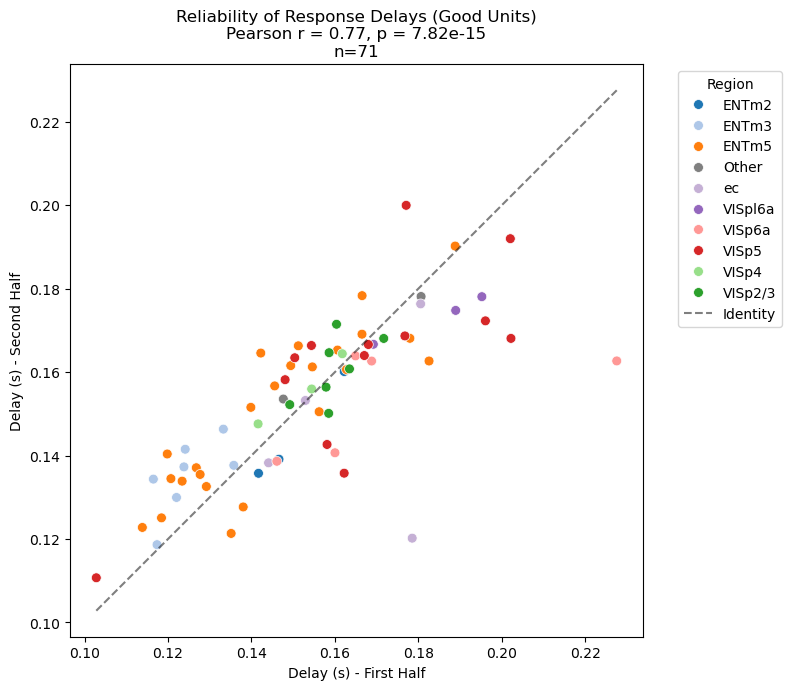

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
from scipy import stats

# ==========================================
# CONFIGURATION
# ==========================================
CONFIG = {
    'WINDOW_START': 0.01,           # Start of responsive window (s)
    'WINDOW_END': 0.3,             # End of responsive window (s) (150ms per paper)
    'BASELINE_PRE': 0.2,            # Baseline window duration (s)
    'BIN_SIZE': 0.005,              # Bin size (5ms)
    'SMOOTH_SIGMA': 1,              # Smoothing sigma (bins)
    
    # --- USER FLAGS ---
    'PLOT_ONLY_GOOD_UNITS': True,   # Set False to plot ALL neurons
    'MIN_TRIALS': 50                # Min trials total
}

# ==========================================
# 1. PREPARE DATA & SPLIT TRIALS
# ==========================================

# Get all valid Stim Onset times
all_events = sl.trials.stimOn_times[~np.isnan(sl.trials.stimOn_times)]
n_total = len(all_events)

# Split into First Half and Second Half
mid_idx = n_total // 2
events_h1 = all_events[:mid_idx]
events_h2 = all_events[mid_idx:]

print(f"Total Trials: {n_total}")
print(f"Split: 1st Half ({len(events_h1)} trials) | 2nd Half ({len(events_h2)} trials)")

# Unique clusters
cluster_ids = np.unique(spikes.clusters)

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================

def get_psth_data(neuron_spikes, event_times, config):
    """
    Returns smoothed firing rate and bin centers for a set of events.
    """
    if len(neuron_spikes) == 0 or len(event_times) == 0:
        return None, None

    # Define time bins
    t_min = -config['BASELINE_PRE']
    t_max = config['WINDOW_END'] + 0.05
    bins = np.arange(t_min, t_max + config['BIN_SIZE'], config['BIN_SIZE'])
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Optimization: Filter spikes to broad window first
    s_min = event_times.min() - config['BASELINE_PRE']
    s_max = event_times.max() + config['WINDOW_END']
    subset_spikes = neuron_spikes[(neuron_spikes >= s_min) & (neuron_spikes <= s_max)]
    
    if len(subset_spikes) == 0:
        return None, None

    # Accumulate relative spike times
    relative_spikes = []
    for t_ev in event_times:
        t0 = t_ev - config['BASELINE_PRE']
        t1 = t_ev + config['WINDOW_END']
        in_trial = subset_spikes[(subset_spikes >= t0) & (subset_spikes <= t1)]
        relative_spikes.append(in_trial - t_ev)
    
    if len(relative_spikes) == 0:
        return None, None
        
    all_rel_spikes = np.concatenate(relative_spikes)
    
    # Histogram & Smooth
    counts, _ = np.histogram(all_rel_spikes, bins=bins)
    fr = counts / len(event_times) / config['BIN_SIZE']
    fr_smooth = gaussian_filter1d(fr, sigma=config['SMOOTH_SIGMA'])
    
    return fr_smooth, bin_centers

def calculate_delay_raw(fr_smooth, bin_centers, config):
    """
    Calculates Center of Mass (Delay) without threshold checks.
    """
    if fr_smooth is None: return np.nan
    
    idx_responsive = (bin_centers >= config['WINDOW_START']) & (bin_centers <= config['WINDOW_END'])
    resp_fr = fr_smooth[idx_responsive]
    resp_time = bin_centers[idx_responsive]
    
    sum_fr = np.sum(resp_fr)
    if sum_fr > 0:
        return np.sum(resp_fr * resp_time) / sum_fr
    return np.nan

def check_is_responsive(fr_smooth, bin_centers, config):
    """
    Checks if neuron crosses baseline threshold.
    """
    if fr_smooth is None: return False
    
    idx_baseline = (bin_centers >= -config['BASELINE_PRE']) & (bin_centers < 0)
    idx_responsive = (bin_centers >= config['WINDOW_START']) & (bin_centers <= config['WINDOW_END'])
    
    baseline_fr = fr_smooth[idx_baseline]
    if len(baseline_fr) == 0: return False
    
    threshold = np.mean(baseline_fr) + 2 * np.std(baseline_fr)
    resp_fr = fr_smooth[idx_responsive]
    
    return np.any(resp_fr > threshold)

# ==========================================
# 3. MAIN LOOP
# ==========================================
results = []
print(f"Processing clusters (Good Units Only: {CONFIG['PLOT_ONLY_GOOD_UNITS']})...")

for cid in cluster_ids:
    # --- METADATA ---
    try:
        acronym = clusters.acronym[cid]
        if hasattr(clusters, 'metrics') and 'label' in clusters.metrics.columns:
            label = clusters.metrics.label[cid]
        elif hasattr(clusters, 'label'):
            label = clusters.label[cid]
        else:
            label = 1 
    except:
        acronym = 'Unknown'
        label = 1
        
    if CONFIG['PLOT_ONLY_GOOD_UNITS'] and label != 1:
        continue

    neuron_spikes = spikes.times[spikes.clusters == cid]
    
    # --- STEP 1: CHECK GLOBAL RESPONSIVENESS (ALL TRIALS) ---
    # We use all trials to decide if the neuron is "responsive enough" to be included.
    fr_all, bins_all = get_psth_data(neuron_spikes, all_events, CONFIG)
    
    if not check_is_responsive(fr_all, bins_all, CONFIG):
        continue
        
    # --- STEP 2: CALCULATE DELAY FOR SPLIT HALVES ---
    # We calculate the delay regardless of whether it crosses the threshold 
    # in the specific half, as long as there is data (sum > 0).
    
    fr_h1, bins_h1 = get_psth_data(neuron_spikes, events_h1, CONFIG)
    delay_h1 = calculate_delay_raw(fr_h1, bins_h1, CONFIG)
    
    fr_h2, bins_h2 = get_psth_data(neuron_spikes, events_h2, CONFIG)
    delay_h2 = calculate_delay_raw(fr_h2, bins_h2, CONFIG)
    
    # Only keep if we got valid numbers for both halves
    if not np.isnan(delay_h1) and not np.isnan(delay_h2):
        results.append({
            'cluster_id': cid,
            'acronym': acronym,
            'delay_h1': delay_h1,
            'delay_h2': delay_h2
        })

df_reliability = pd.DataFrame(results)
print(f"Found {len(df_reliability)} globally responsive neurons (with valid delays in both halves).")

# ==========================================
# 4. PLOTTING
# ==========================================

if len(df_reliability) > 0:
    # 1. Determine Region Categories (Top N + Other)
    top_n = 9 
    region_counts = df_reliability['acronym'].value_counts()
    top_regions = region_counts.nlargest(top_n).index.tolist()
    
    if 'VISp' in df_reliability['acronym'].values and 'VISp' not in top_regions:
        top_regions.append('VISp')
            
    df_reliability['plot_region'] = df_reliability['acronym'].apply(lambda x: x if x in top_regions else 'Other')
    
    # 2. Custom Palette (Solid Colors)
    unique_plot_regions = sorted(df_reliability['plot_region'].unique())
    default_colors = sns.color_palette("tab20", n_colors=len(unique_plot_regions))
    palette_dict = dict(zip(unique_plot_regions, default_colors))
    
    if 'VISp' in palette_dict:
        palette_dict['VISp'] = 'blue'  # Force Blue
    if 'Other' in palette_dict:
        palette_dict['Other'] = 'gray'

    # 3. Calculate Pearson r
    r_val, p_val = stats.pearsonr(df_reliability['delay_h1'], df_reliability['delay_h2'])
    
    # 4. Plot
    fig, ax = plt.subplots(figsize=(8, 8))
    
    sns.scatterplot(
        data=df_reliability, 
        x='delay_h1', 
        y='delay_h2', 
        hue='plot_region',
        palette=palette_dict,
        marker='o',    # Simple circle
        s=50, 
        alpha=1.0,     # No transparency
        ax=ax,
        edgecolor='white', # Slight outline for clarity
        linewidth=0.5
    )
    
    # Identity Line
    lims = [
        min(df_reliability['delay_h1'].min(), df_reliability['delay_h2'].min()),
        max(df_reliability['delay_h1'].max(), df_reliability['delay_h2'].max())
    ]
    ax.plot(lims, lims, color='black', linestyle='--', alpha=0.5, label='Identity')
    
    # Styling
    ax.set_xlabel('Delay (s) - First Half')
    ax.set_ylabel('Delay (s) - Second Half')
    
    unit_type = "Good Units" if CONFIG['PLOT_ONLY_GOOD_UNITS'] else "All Units"
    ax.set_title(f'Reliability of Response Delays ({unit_type})\nPearson r = {r_val:.2f}, p = {p_val:.2e}\nn={len(df_reliability)}')
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Region')
    ax.axis('square')
    plt.tight_layout()
    plt.show()

else:
    print("No neurons met the criteria.")

In [ ]:
# Add the delay caculation for inhibitions as well 
#'NEURON_TO_PLOT': 462,  


Analyzing Cluster ID: 725 | Region: VISp5
Global Delay found: 0.0880 s


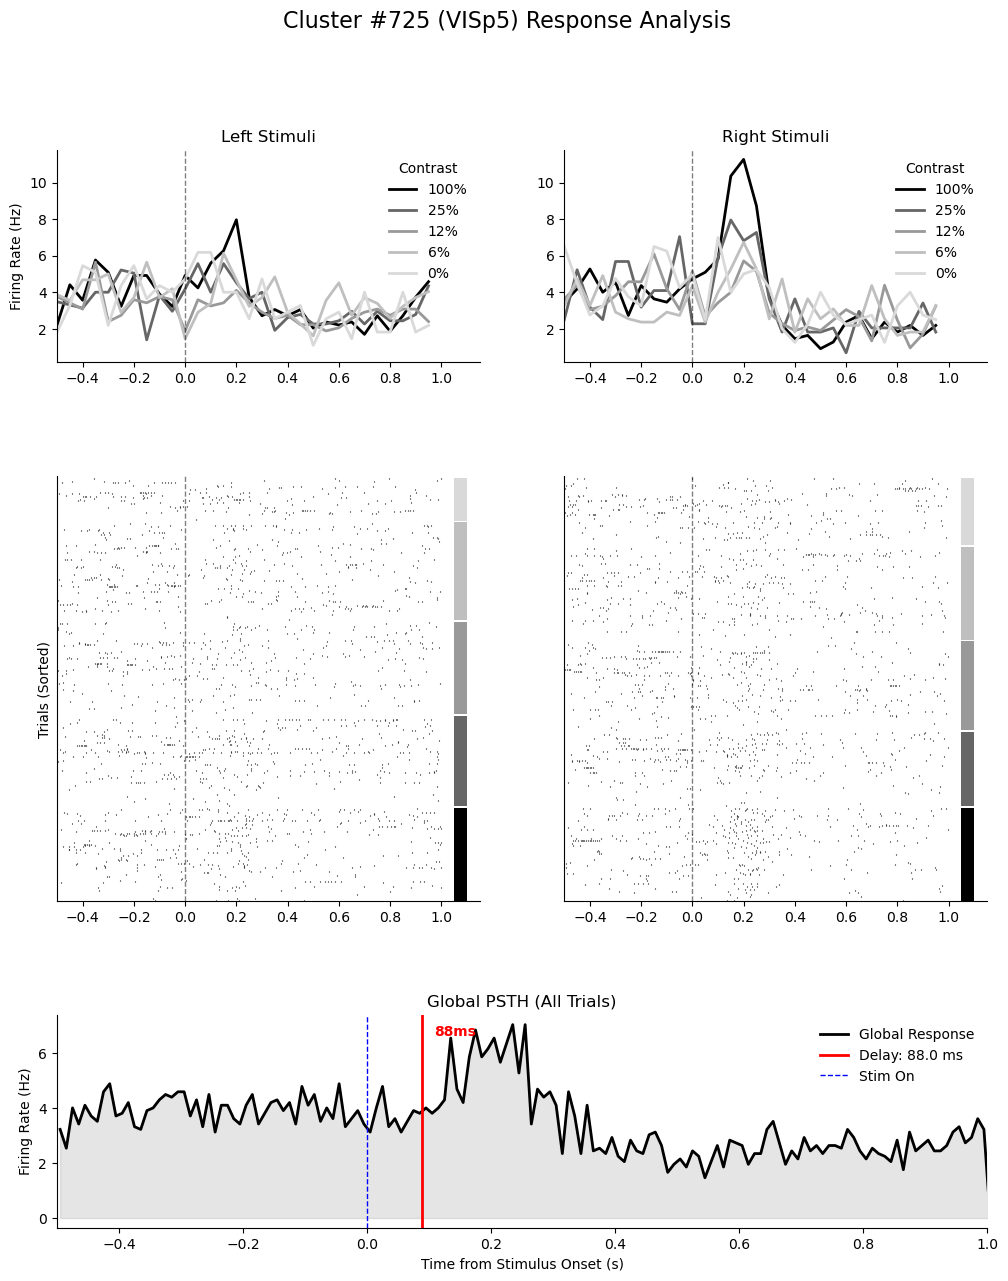

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from scipy.ndimage import gaussian_filter1d

# ==========================================
# CONFIGURATION
# ==========================================
CONFIG = {
    'NEURON_TO_PLOT': 725,          # DIRECT CLUSTER ID (The specific ID label of the neuron)
    'RASTER_WINDOW_PRE': 0.5,       # Seconds before Stim On
    'RASTER_WINDOW_POST': 1.0,      # Seconds after Stim On
    'BIN_SIZE': 0.05,               # Bin size for PSTH (s)
    'SMOOTH_SIGMA': 1               # Smoothing for global PSTH
}

# ==========================================
# 1. IDENTIFY NEURON & RETRIEVE DELAY
# ==========================================
try:
    # --- DIRECT SELECTION BY CLUSTER ID ---
    target_cluster_id = CONFIG['NEURON_TO_PLOT']
    
    # Check if this ID exists in the clusters object (bounds check)
    if target_cluster_id >= len(clusters.acronym):
        print(f"Error: Cluster ID {target_cluster_id} is out of bounds (Max ID: {len(clusters.acronym)-1}).")
        # Fallback to 0 if invalid
        target_cluster_id = 0
        
    # Get the region for this specific cluster
    target_acronym = clusters.acronym[target_cluster_id]
    print(f"Analyzing Cluster ID: {target_cluster_id} | Region: {target_acronym}")

    # --- RETRIEVE DELAY FROM df_res ---
    # Check if df_res exists and has this cluster
    unit_delay = np.nan
    if 'df_res' in locals():
        match = df_res[df_res['cluster_id'] == target_cluster_id]
        if not match.empty:
            unit_delay = match.iloc[0]['delay']
            print(f"Global Delay found: {unit_delay:.4f} s")
        else:
            print(f"Cluster {target_cluster_id} not found in df_res (unit might be unresponsive).")
    else:
        print("Warning: 'df_res' dataframe not found. Cannot plot delay line.")

except AttributeError:
    print("Error: clusters.acronym not found or incomplete data.")
    target_cluster_id = 0
    target_acronym = "Unknown"
    unit_delay = np.nan

# ==========================================
# 2. PLOTTING SETUP (GridSpec)
# ==========================================

# Create Figure with 3 Rows: 
# Row 0: Split PSTHs
# Row 1: Split Rasters
# Row 2: Global PSTH (Spanning width)
fig = plt.figure(figsize=(12, 14))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 2, 1], hspace=0.4)

ax_psth_L = fig.add_subplot(gs[0, 0])
ax_psth_R = fig.add_subplot(gs[0, 1], sharey=ax_psth_L)
ax_rast_L = fig.add_subplot(gs[1, 0], sharex=ax_psth_L)
ax_rast_R = fig.add_subplot(gs[1, 1], sharex=ax_psth_R)
ax_global = fig.add_subplot(gs[2, :]) # Spans both columns

# Group axes for easier looping
axes_split = [[ax_psth_L, ax_psth_R], [ax_rast_L, ax_rast_R]]

# Get spikes for the target neuron only
neuron_spikes = spikes.times[spikes.clusters == target_cluster_id]

# Define Contrast Levels and Colors
contrasts_to_plot = [1.0, 0.25, 0.125, 0.0625, 0.0]
contrast_colors = {
    1.0:    (0.0, 0.0, 0.0, 1.0),   # Black
    0.5:    (0.2, 0.2, 0.2, 1.0),
    0.25:   (0.4, 0.4, 0.4, 1.0),
    0.125:  (0.6, 0.6, 0.6, 1.0),
    0.0625: (0.75, 0.75, 0.75, 1.0), # Light Gray
    0.0:    (0.85, 0.85, 0.85, 1.0)  # Very Light Gray
}

# ==========================================
# 3. PLOT ROWS 1 & 2 (Split Left/Right)
# ==========================================

sides = ['Left', 'Right']
for col_idx, side in enumerate(sides):
    
    ax_psth = axes_split[0][col_idx]
    ax_rast = axes_split[1][col_idx]
    
    current_raster_y = 0
    
    for cont in contrasts_to_plot:
        
        # --- Filter Trials ---
        if side == 'Left':
            contrast_arr = sl.trials.contrastLeft
        else:
            contrast_arr = sl.trials.contrastRight
            
        mask = (contrast_arr == cont) & (~np.isnan(sl.trials.stimOn_times))
        events = sl.trials.stimOn_times[mask]
        
        if len(events) == 0:
            continue
            
        # --- PSTH Calculation ---
        psth_spikes_concat = []
        for event_t in events:
            t_start = event_t - CONFIG['RASTER_WINDOW_PRE']
            t_end = event_t + CONFIG['RASTER_WINDOW_POST']
            in_window = neuron_spikes[(neuron_spikes >= t_start) & (neuron_spikes <= t_end)]
            psth_spikes_concat.append(in_window - event_t)
            
        psth_bins = np.arange(-CONFIG['RASTER_WINDOW_PRE'], 
                              CONFIG['RASTER_WINDOW_POST'] + CONFIG['BIN_SIZE'], 
                              CONFIG['BIN_SIZE'])
        
        if len(psth_spikes_concat) > 0:
            all_spikes = np.concatenate(psth_spikes_concat)
            counts, _ = np.histogram(all_spikes, bins=psth_bins)
            firing_rate = counts / len(events) / CONFIG['BIN_SIZE']
        else:
            firing_rate = np.zeros(len(psth_bins)-1)
            
        color_val = contrast_colors.get(cont, (0,0,0,1))
        label_text = f'{cont*100:.0f}%' if cont > 0 else '0%'
        ax_psth.plot(psth_bins[:-1], firing_rate, color=color_val, linewidth=2, label=label_text)

        # --- Raster Calculation ---
        block_start_y = current_raster_y
        for event_t in events:
            t_start = event_t - CONFIG['RASTER_WINDOW_PRE']
            t_end = event_t + CONFIG['RASTER_WINDOW_POST']
            trial_spikes = neuron_spikes[(neuron_spikes >= t_start) & (neuron_spikes <= t_end)]
            aligned_spikes = trial_spikes - event_t
            
            ax_rast.vlines(aligned_spikes, current_raster_y - 0.4, current_raster_y + 0.4, 
                           colors='black', linewidth=0.8)
            current_raster_y += 1
            
        # --- Color Bar ---
        bar_x = CONFIG['RASTER_WINDOW_POST'] + 0.05
        rect = patches.Rectangle((bar_x, block_start_y), 0.05, current_raster_y - block_start_y, 
                                 linewidth=0, facecolor=color_val, clip_on=False)
        ax_rast.add_patch(rect)
        current_raster_y += 2

    # Formatting Split Plots
    ax_psth.set_title(f'{side} Stimuli')
    ax_psth.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
    ax_rast.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
    ax_psth.legend(frameon=False, title='Contrast')
    
    # Hide spines
    for ax in [ax_psth, ax_rast]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    ax_rast.set_yticks([])
    ax_rast.set_xlim(-CONFIG['RASTER_WINDOW_PRE'], CONFIG['RASTER_WINDOW_POST'] + 0.15)
    ax_rast.set_ylim(-1, current_raster_y)
    
    # Labels
    if col_idx == 0:
        ax_psth.set_ylabel('Firing Rate (Hz)')
        ax_rast.set_ylabel('Trials (Sorted)')

# ==========================================
# 4. PLOT ROW 3: GLOBAL PSTH & DELAY
# ==========================================

# Get ALL Stim Onset events (ignore NaN)
all_events = sl.trials.stimOn_times[~np.isnan(sl.trials.stimOn_times)]

if len(all_events) > 0:
    # --- Compute Global PSTH ---
    psth_spikes_global = []
    
    # NOTE: Using slightly finer bin size for global plot for smoother appearance
    bins_global = np.arange(-CONFIG['RASTER_WINDOW_PRE'], 
                            CONFIG['RASTER_WINDOW_POST'] + CONFIG['BIN_SIZE'], 
                            0.01) 
    
    # Collect spikes
    # Optimization: Filter roughly first
    s_min = all_events.min() - CONFIG['RASTER_WINDOW_PRE']
    s_max = all_events.max() + CONFIG['RASTER_WINDOW_POST']
    subset_spikes = neuron_spikes[(neuron_spikes >= s_min) & (neuron_spikes <= s_max)]
    
    for t_ev in all_events:
        t0 = t_ev - CONFIG['RASTER_WINDOW_PRE']
        t1 = t_ev + CONFIG['RASTER_WINDOW_POST']
        in_trial = subset_spikes[(subset_spikes >= t0) & (subset_spikes <= t1)]
        psth_spikes_global.append(in_trial - t_ev)
        
    if len(psth_spikes_global) > 0:
        all_spikes_global = np.concatenate(psth_spikes_global)
        counts_g, _ = np.histogram(all_spikes_global, bins=bins_global)
        
        # Calculate Rate
        fr_global = counts_g / len(all_events) / 0.01
        
        # Smooth
        fr_global_smooth = gaussian_filter1d(fr_global, sigma=2) 
        
        # Plot
        bin_centers = (bins_global[:-1] + bins_global[1:]) / 2
        ax_global.plot(bin_centers, fr_global, color='k', linewidth=2, label='Global Response')
        ax_global.fill_between(bin_centers, fr_global, color='gray', alpha=0.2)
        
        # --- Plot Delay Line ---
        if not np.isnan(unit_delay):
            # Draw vertical red line
            ax_global.axvline(unit_delay, color='red', linestyle='-', linewidth=2, label=f'Delay: {unit_delay*1000:.1f} ms')
            # Add text
            ymax = ax_global.get_ylim()[1]
            if ymax > 0: # Avoid error if flat line
                ax_global.text(unit_delay + 0.02, ymax*0.9, f'{unit_delay*1000:.0f}ms', color='red', fontsize=10, fontweight='bold')
    
    # Formatting
    ax_global.axvline(0, color='blue', linestyle='--', linewidth=1, label='Stim On')
    ax_global.set_ylabel('Firing Rate (Hz)')
    ax_global.set_xlabel('Time from Stimulus Onset (s)')
    ax_global.set_title('Global PSTH (All Trials)')
    ax_global.legend(loc='upper right', frameon=False)
    ax_global.spines['top'].set_visible(False)
    ax_global.spines['right'].set_visible(False)
    ax_global.set_xlim(-CONFIG['RASTER_WINDOW_PRE'], CONFIG['RASTER_WINDOW_POST'])

else:
    ax_global.text(0.5, 0.5, "No valid trials found", ha='center')

# Final Title & Show
plt.suptitle(f'Cluster #{target_cluster_id} ({target_acronym}) Response Analysis', fontsize=16)
plt.show()

Plotting Sequence Raster for Trial 161 (Good Units Only)...
Found 41 Good Neurons in VISp layers.
Sorting Complete: 22 sequenced, 19 unresponsive (bottom).
Drawing raster lines...


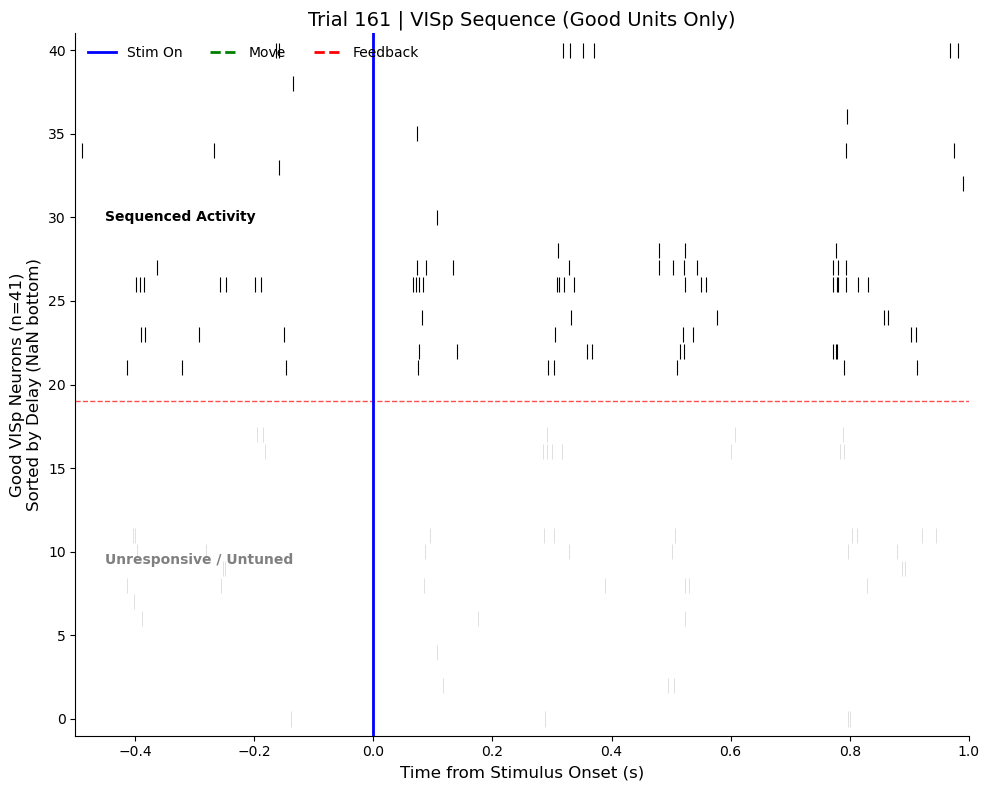

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================
# CONFIGURATION
# ==========================================
TRIAL_IDX = CONFIG.get('RASTER_TRIAL_IDX', 161) 
WINDOW_PRE = CONFIG.get('RASTER_WINDOW_PRE', 0.5)
WINDOW_POST = CONFIG.get('RASTER_WINDOW_POST', 1.0)
ALIGN_TO_STIM = True

print(f"Plotting Sequence Raster for Trial {TRIAL_IDX} (Good Units Only)...")

# ==========================================
# 1. DATA PREPARATION (FILTERED)
# ==========================================

# --- A. Filter for VISp Neurons AND Good Quality ---
try:
    # 1. Region Mask (VISp)
    visp_mask = np.char.startswith(clusters.acronym.astype(str), 'VISp')
    
    # 2. Quality Mask (Label == 1)
    if hasattr(clusters, 'metrics') and 'label' in clusters.metrics.columns:
        quality_mask = clusters.metrics.label == 1
    elif hasattr(clusters, 'label'):
        quality_mask = clusters.label == 1
    else:
        print("Warning: Cluster labels not found. Using all units.")
        quality_mask = np.ones(len(clusters.acronym), dtype=bool)

    # Combine Masks
    final_mask = visp_mask & quality_mask
    visp_cluster_ids = np.where(final_mask)[0]
    
    print(f"Found {len(visp_cluster_ids)} Good Neurons in VISp layers.")

except AttributeError:
    print("Error: clusters data incomplete.")
    visp_cluster_ids = []

# --- B. Merge with Delay Data (df_res) ---
df_visp = pd.DataFrame({
    'cluster_id': visp_cluster_ids,
    'acronym': clusters.acronym[visp_cluster_ids],
    'depth': clusters.depths[visp_cluster_ids]
})

if 'df_res' in locals():
    # Left join to keep all selected neurons, even if they don't have a delay (NaN)
    df_visp = df_visp.merge(df_res[['cluster_id', 'delay']], on='cluster_id', how='left')
else:
    print("Warning: 'df_res' not found. Sorting by depth instead.")
    df_visp['delay'] = np.nan

# --- C. SORTING LOGIC ---
# NaNs at the bottom, then sorted by delay (Early -> Late)
df_sorted = df_visp.sort_values(by='delay', ascending=True, na_position='first').reset_index(drop=True)

n_responsive = df_sorted['delay'].notna().sum()
n_nan = df_sorted['delay'].isna().sum()
print(f"Sorting Complete: {n_responsive} sequenced, {n_nan} unresponsive (bottom).")

# ==========================================
# 2. TRIAL TIMING
# ==========================================
t_stim = sl.trials['stimOn_times'][TRIAL_IDX]
t_move = sl.trials['firstMovement_times'][TRIAL_IDX]
t_feed = sl.trials['feedback_times'][TRIAL_IDX]

t_start = t_stim - WINDOW_PRE
t_end = t_stim + WINDOW_POST
t_offset = t_stim if ALIGN_TO_STIM else 0

# --- Filter Spikes Globally for Speed ---
mask_spikes = (np.isin(spikes.clusters, visp_cluster_ids)) & \
              (spikes.times >= t_start) & (spikes.times <= t_end)
              
relevant_spikes = spikes.times[mask_spikes]
relevant_clusters = spikes.clusters[mask_spikes]

# ==========================================
# 3. PLOTTING
# ==========================================
fig, ax_raster = plt.subplots(figsize=(10, 8))

print("Drawing raster lines...")

# Iterate and plot
for y_idx, row in df_sorted.iterrows():
    cid = row['cluster_id']
    delay = row['delay']
    
    # Get spikes for this unit
    unit_spikes = relevant_spikes[relevant_clusters == cid]
    
    if len(unit_spikes) > 0:
        # Align spikes
        spike_times_aligned = unit_spikes - t_offset
        
        # Color logic
        if pd.isna(delay):
            color = 'lightgray' # NaN delay -> Bottom, Gray
            lw = 0.5
        else:
            color = 'black' 
            lw = 0.8
            
        ax_raster.vlines(spike_times_aligned, y_idx - 0.45, y_idx + 0.45, color=color, linewidth=lw)

# Raster Styling
ax_raster.set_xlim(t_start - t_offset, t_end - t_offset)
ax_raster.set_ylim(-1, len(df_sorted))
ax_raster.set_ylabel(f'Good VISp Neurons (n={len(df_sorted)})\nSorted by Delay (NaN bottom)', fontsize=12)
ax_raster.set_xlabel('Time from Stimulus Onset (s)', fontsize=12)
ax_raster.set_title(f'Trial {TRIAL_IDX} | VISp Sequence (Good Units Only)', fontsize=14)

# Add dividers/labels
if n_nan > 0:
    ax_raster.axhline(n_nan, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax_raster.text( (t_start - t_offset) + 0.05, n_nan/2, 'Unresponsive / Untuned', 
                   color='gray', fontsize=10, va='center', fontweight='bold')
    ax_raster.text( (t_start - t_offset) + 0.05, n_nan + (n_responsive/2), 'Sequenced Activity', 
                   color='black', fontsize=10, va='center', fontweight='bold')

# Events
ax_raster.axvline(0, color='blue', linewidth=2, label='Stim On') # 0 if aligned to Stim
if not np.isnan(t_move):
    ax_raster.axvline(t_move - t_offset, color='green', linewidth=2, linestyle='--', label='Move')
if not np.isnan(t_feed):
    ax_raster.axvline(t_feed - t_offset, color='red', linewidth=2, linestyle='--', label='Feedback')

ax_raster.legend(loc='upper left', frameon=False, ncol=3)

# Remove top/right spines
ax_raster.spines['top'].set_visible(False)
ax_raster.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Preparing sorted neuron list...
Found 41 Good Neurons in VISp.
Calculating PSTH matrix...


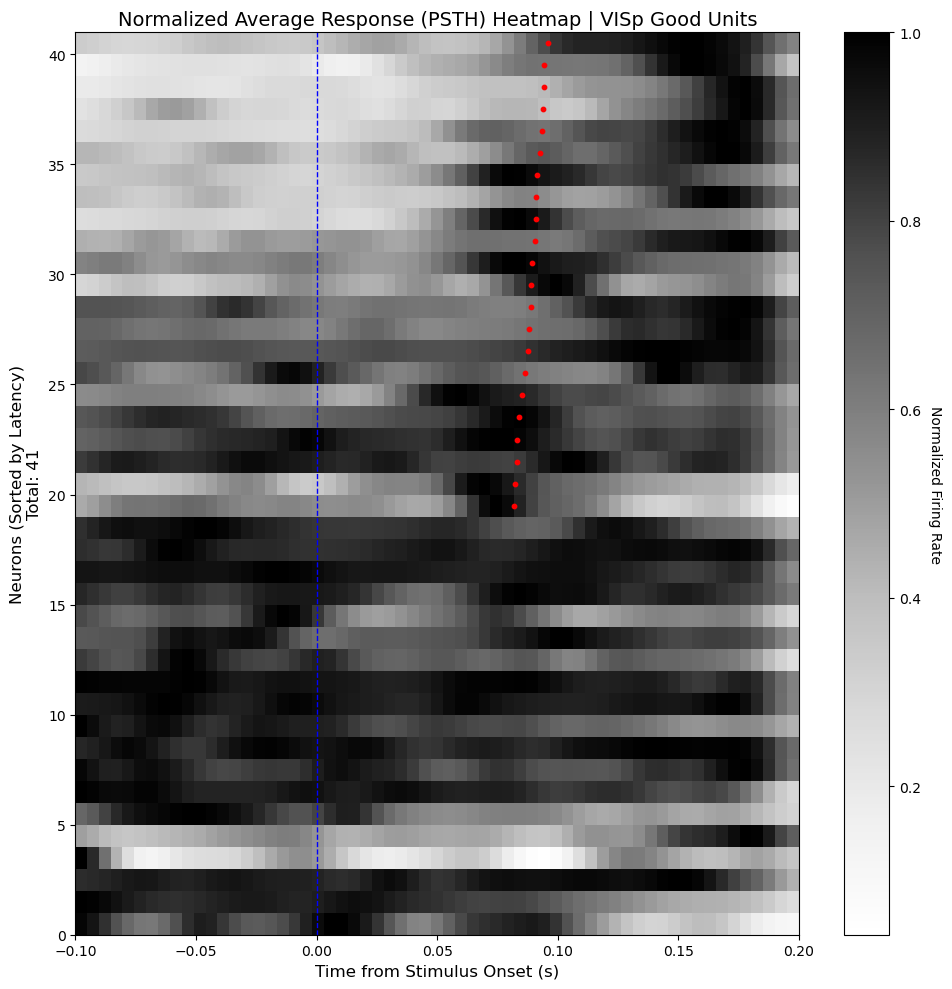

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d

# ==========================================
# CONFIGURATION
# ==========================================
WINDOW_PRE = 0.1        # Seconds before Stim On
WINDOW_POST = 0.2       # Seconds after Stim On
BIN_SIZE = 0.005        # 5ms bins
SMOOTH_SIGMA = 2        # Smoothing (bins)
CMAP_NAME = 'Greys'     # Color map ('Greys', 'viridis', 'plasma', 'binary', etc.)
NORMALIZE = True        # Normalize each neuron to its peak? (Recommended for visibility)

# ==========================================
# 1. PREPARE DATA (VISp + Good + Sorted)
# ==========================================
print("Preparing sorted neuron list...")

# A. Filter Good VISp Neurons
try:
    visp_mask = np.char.startswith(clusters.acronym.astype(str), 'VISp')
    
    if hasattr(clusters, 'metrics') and 'label' in clusters.metrics.columns:
        quality_mask = clusters.metrics.label == 1
    elif hasattr(clusters, 'label'):
        quality_mask = clusters.label == 1
    else:
        quality_mask = np.ones(len(clusters.acronym), dtype=bool)

    final_mask = visp_mask & quality_mask
    visp_ids = np.where(final_mask)[0]
    print(f"Found {len(visp_ids)} Good Neurons in VISp.")

except AttributeError:
    visp_ids = []
    print("Error: Cluster data incomplete.")

# B. Merge with Delays
df_visp = pd.DataFrame({'cluster_id': visp_ids})

if 'df_res' in locals():
    df_visp = df_visp.merge(df_res[['cluster_id', 'delay']], on='cluster_id', how='left')
else:
    print("Warning: df_res not found. Latencies will be NaN.")
    df_visp['delay'] = np.nan

# C. Sort (NaNs at bottom)
df_sorted = df_visp.sort_values(by='delay', ascending=True, na_position='first').reset_index(drop=True)

# ==========================================
# 2. CALCULATE PSTH MATRIX
# ==========================================
print("Calculating PSTH matrix...")

# Time bins
bins = np.arange(-WINDOW_PRE, WINDOW_POST + BIN_SIZE, BIN_SIZE)
bin_centers = (bins[:-1] + bins[1:]) / 2
n_bins = len(bin_centers)
n_neurons = len(df_sorted)

# Initialize Matrix (Rows=Neurons, Cols=Time)
psth_matrix = np.zeros((n_neurons, n_bins))

# Get all valid stim times
stim_times = sl.trials['stimOn_times'][~np.isnan(sl.trials['stimOn_times'])]

# Loop through sorted neurons
for row_idx, row in df_sorted.iterrows():
    cid = row['cluster_id']
    
    # Get all spikes for this neuron
    # Optimization: Filter roughly by session bounds first if dataset is huge, 
    # but for typical IBL sessions, boolean indexing is okay.
    unit_spikes = spikes.times[spikes.clusters == cid]
    
    if len(unit_spikes) == 0:
        continue

    # PSTH Calculation (Accumulate relative times)
    # We collect all relative spike times across all trials
    all_rel_spikes = []
    
    # Optimization: Chunking or simple loop
    # Using a loop over trials is clearer. 
    # For very fast calculation, bincount2D is better, but this is robust.
    t_min = stim_times.min() - WINDOW_PRE
    t_max = stim_times.max() + WINDOW_POST
    subset = unit_spikes[(unit_spikes >= t_min) & (unit_spikes <= t_max)]
    
    for t_stim in stim_times:
        t0 = t_stim - WINDOW_PRE
        t1 = t_stim + WINDOW_POST
        in_window = subset[(subset >= t0) & (subset <= t1)]
        all_rel_spikes.append(in_window - t_stim)
    
    if len(all_rel_spikes) > 0:
        flat_spikes = np.concatenate(all_rel_spikes)
        counts, _ = np.histogram(flat_spikes, bins=bins)
        
        # Convert to Hz
        fr = counts / len(stim_times) / BIN_SIZE
        
        # Smooth
        fr_smooth = gaussian_filter1d(fr, sigma=SMOOTH_SIGMA)
        
        # Normalize (Optional but Recommended for Heatmaps)
        if NORMALIZE:
            peak = np.max(fr_smooth)
            if peak > 0:
                fr_smooth = fr_smooth / peak
        
        psth_matrix[row_idx, :] = fr_smooth

# ==========================================
# 3. PLOTTING
# ==========================================
fig, ax = plt.subplots(figsize=(10, 10))

# Plot Heatmap
# aspect='auto' fills the plot area
# origin='lower' puts index 0 at the bottom (matching our sorting logic)
im = ax.imshow(psth_matrix, 
               aspect='auto', 
               origin='lower',
               extent=[-WINDOW_PRE, WINDOW_POST, 0, n_neurons],
               cmap=CMAP_NAME,
               interpolation='nearest')

# Plot Red Dots (Delays)
# We overlay a scatter plot. Y-coordinate is simply the row index + 0.5 (center of pixel)
valid_delays = df_sorted.dropna(subset=['delay'])
# Use the index from df_sorted as the Y position
y_positions = valid_delays.index + 0.5 
x_positions = valid_delays['delay']

ax.scatter(x_positions, y_positions, color='red', s=10, marker='o', label='Calculated Latency')

# Formatting
ax.axvline(0, color='blue', linestyle='--', linewidth=1, label='Stim On')
ax.set_xlabel('Time from Stimulus Onset (s)', fontsize=12)
ax.set_ylabel(f'Neurons (Sorted by Latency)\nTotal: {n_neurons}', fontsize=12)
title_str = "Normalized " if NORMALIZE else "Raw "
ax.set_title(f'{title_str}Average Response (PSTH) Heatmap | VISp Good Units', fontsize=14)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Normalized Firing Rate' if NORMALIZE else 'Firing Rate (Hz)', rotation=270, labelpad=15)

# Limits
ax.set_xlim(-WINDOW_PRE, WINDOW_POST)
ax.set_ylim(0, n_neurons)

plt.tight_layout()
plt.show()